## 바이오 빅데이터 분석 (1A): Python/Pandas Bridge + Visualization Practice

### 이 노트북의 목적
이 노트북은 파이썬 기초 문법을 한 번 배운 수강생이 실제 바이오 빅데이터 분석 코드로 넘어가기 위한 실습 자료입니다.  
문법 자체를 길게 반복하기보다는, 생명과학/의학 데이터 분석에서 자주 쓰는 `pandas DataFrame`과 기본 시각화 흐름을 실제 데이터로 연습합니다.

### 실습 주제
1. 바이오 데이터 테이블 구조 이해와 pandas DataFrame 핵심 복습
2. TCGA-BRCA 유방암 데이터의 gene expression과 clinical metadata 다루기
3. DataFrame 선택, 조건 필터링, `groupby`, table 결합 연습
4. 데이터 분포 시각화: histogram, pairplot, boxplot, violin plot, heatmap

### 사용할 데이터
1. CancerSEEK data: 단백질 marker와 임상 정보
2. TCGA-BRCA cohort: 유방암 gene expression과 clinical subtype
3. CCLE-CTRPv2: 암세포주 gene expression과 약물 반응 AUC

#### Machine Learning and Bioinformatics (MLBI) Lab


## 0. 필요한 패키지 설치 (처음 한번만 하면 됨)

In [116]:
# !ls 현재 파일 보여주는 것
!ls sample_data

anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [117]:
!python --version
# !pip list 패키지가 뭐 설치되어있는지

Python 3.12.13


In [118]:
# 수업 환경에서 mlbi-lab 또는 scikit-network가 없을 때만 주석을 해제하고 실행하세요.
# 밑에 3가지 패키지를 설치하는 것임
!pip install mlbi-lab scikit-network statannotations

In [119]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, kruskal

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import cluster, mixture
from sklearn.neighbors import kneighbors_graph

from sknetwork.clustering import Louvain
from mlbi.datasets import load_data

In [120]:
load_data()

You can select one of:
  cancerseek
  ccle-ctrpv2
  heart_failure
  hotel_bookings
  house_price
  labor_force
  metabric
  scores
  tcga-brca
  time-series
  time-series2


## 1. Data Frame의 구조와 활용법 실습

### 분석 관점에서 보는 DataFrame

생명과학/의학 데이터 분석에서는 대부분의 자료가 표 형태로 정리됩니다.

- 행(row): 샘플, 환자, 세포주, 실험 조건
- 열(column): 유전자, 단백질, 임상 변수, 약물 반응값
- index: 각 행을 구분하는 이름 또는 ID
- values: 실제 측정값

엑셀과 비슷해 보이지만, `pandas DataFrame`은 행/열 선택, 조건 필터링, 통계 요약, 시각화 연동을 코드로 재현할 수 있다는 점이 중요합니다.

In [121]:
# 아주 작은 예제 DataFrame을 먼저 만들어 봅니다.
# 실제 바이오 데이터도 구조는 이 예제와 같습니다.

example_df = pd.DataFrame({
    'sample_id': ['S1', 'S2', 'S3', 'S4'],
    'subtype': ['Lum.A', 'Lum.B', 'Basal', 'Her2'],
    'ESR1': [12.4, 8.1, 1.2, 4.5],
    'ERBB2': [3.1, 4.0, 2.8, 14.2],
    'MKI67': [2.3, 7.8, 9.1, 6.5]
})

example_df

,sample_id,subtype,ESR1,ERBB2,MKI67
0,S1,Lum.A,12.4,3.1,2.3
1,S2,Lum.B,8.1,4.0,7.8
2,S3,Basal,1.2,2.8,9.1
3,S4,Her2,4.5,14.2,6.5


In [122]:
example_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  4 non-null      object 
 1   subtype    4 non-null      object 
 2   ESR1       4 non-null      float64
 3   ERBB2      4 non-null      float64
 4   MKI67      4 non-null      float64
dtypes: float64(3), object(2)
memory usage: 292.0+ bytes


In [123]:
example_df['ESR1'].mean()

np.float64(6.55)

### 빠른 복습: 한 열과 여러 열 선택

`df['ESR1']`은 한 열을 `Series`로 가져오고, `df[['ESR1', 'ERBB2']]`는 여러 열을 `DataFrame`으로 가져옵니다.  
대괄호가 하나인지 두 개인지에 따라 결과의 타입이 달라진다는 점을 자주 확인하세요.

In [124]:
print(type(example_df['ESR1']))
print(type(example_df[['ESR1', 'ERBB2']]))

example_df[['ESR1', 'ERBB2']].std()

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,0
ESR1,4.811445
ERBB2,5.473801


### 빠른 복습: 조건으로 샘플 고르기

아래 예시는 `ESR1` 발현량이 높은 샘플만 고르는 코드입니다.  
실제 분석에서는 특정 subtype, 특정 stage, 특정 발현량 기준에 맞는 샘플을 고를 때 같은 방식을 씁니다.

In [125]:
high_esr1 = example_df[example_df['ESR1'] > 5]
high_esr1

,sample_id,subtype,ESR1,ERBB2,MKI67
0,S1,Lum.A,12.4,3.1,2.3
1,S2,Lum.B,8.1,4.0,7.8


In [126]:
california_df = pd.read_csv('sample_data/california_housing_train.csv', sep = ',')
display(california_df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


<Axes: >

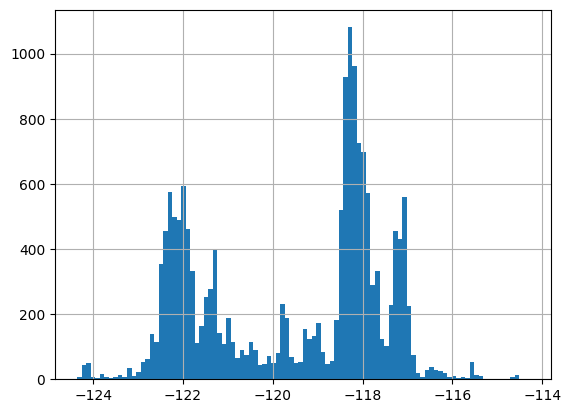

In [127]:
california_df['longitude'].hist(bins = 100)

In [128]:
# example_df.to_csv('example.csv')

### 데이터 불러오기 - CancerSEEK data

In [129]:
load_data()

You can select one of:
  cancerseek
  ccle-ctrpv2
  heart_failure
  hotel_bookings
  house_price
  labor_force
  metabric
  scores
  tcga-brca
  time-series
  time-series2


In [130]:
data = load_data('cancerseek')
data.keys()

dict_keys(['protein_expression', 'clinical_info'])

In [131]:
type(data)

dict

In [132]:
df_pep = data['protein_expression']
df_clinical = data['clinical_info']

df_pep.head()

,AFP,Angiopoietin-2,AXL,CA-125,CA 15-3,CA19-9,CD44,CEA,CYFRA 21-1,DKK1,...,Prolactin,sEGFR,sFas,SHBG,sHER2/sEGFR2/sErbB2,sPECAM-1,TGFa,Thrombospondin-2,TIMP-1,TIMP-2
Sample ID #,,,,,,,,,,,,,,,,,,,,,
CRC 455 PLS 1,1583.450,5598.50,3621.04,5.090,19.08,16.452,9.81,540.0,1938.654,0.78,...,11606.60,3284.17,204.792,55.06,6832.07,9368.53,16.086,21863.74,56428.71,39498.82
CRC 456 PLS 1,715.308,20936.35,2772.96,7.270,10.04,40.910,27.57,5902.0,1938.654,0.77,...,14374.99,1911.81,204.792,72.92,5549.47,6224.55,16.086,29669.66,73940.49,41277.09
CRC 457 PLS 1,4365.530,2350.93,4120.77,4.854,16.96,16.452,14.59,974.0,1976.940,0.90,...,38375.00,1743.94,204.792,173.78,3698.16,4046.48,179.030,6020.47,22797.28,28440.60
CRC 458 PLS 1,715.308,1604.34,2029.96,5.390,8.31,16.452,7.78,2028.0,1938.654,0.64,...,12072.51,1059.24,204.792,29.47,5856.00,6121.93,16.086,4331.02,20441.19,25896.73
CRC 459 PLS 1,801.300,2087.57,2069.17,4.854,11.73,16.452,12.21,615.0,1938.654,0.78,...,23718.17,1736.92,204.792,78.07,5447.93,6982.32,16.086,2311.91,56288.51,49425.20


In [133]:
df_pep.shape, df_clinical.shape

((1803, 39), (1803, 11))

In [134]:
df_clinical

,Patient ID #,Tumor type,AJCC Stage,Age,Gender,Race,Histopathology,CancerSEEK Logistic Regression Score,CancerSEEK Test Result,lc_cnt,uc_cnt
Sample ID #,,,,,,,,,,,
CRC 455 PLS 1,CRC 455,Colorectum,I,60,Male,Caucasian,Adenocarcinoma,0.938,Positive,8,0
CRC 456 PLS 1,CRC 456,Colorectum,I,59,Female,Caucasian,Adenocarcinoma,0.925,Positive,5,0
CRC 457 PLS 1,CRC 457,Colorectum,II,69,Female,Caucasian,Adenocarcinoma,0.852,Negative,6,0
CRC 458 PLS 1,CRC 458,Colorectum,II,70,Female,Caucasian,Adenocarcinoma,0.618,Negative,6,0
CRC 459 PLS 1,CRC 459,Colorectum,II,43,Female,Caucasian,Adenocarcinoma,0.318,Negative,10,0
...,...,...,...,...,...,...,...,...,...,...,...
PAPA 1353 PLS 1,PAPA 1353,Ovary,I,55,Female,Caucasian,Epithelial carcinoma,0.980,Positive,7,0
PAPA 1354 PLS 1,PAPA 1354,Ovary,I,57,Female,Caucasian,Epithelial carcinoma,1.000,Positive,9,0
PAPA 1355 PLS 1,PAPA 1355,Ovary,III,60,Female,Caucasian,Epithelial carcinoma,1.000,Positive,8,0


In [135]:
df_clinical['AJCC Stage'].value_counts()

,count
AJCC Stage,
II,497
III,308
I,199


In [136]:
df_clinical['Tumor type'].value_counts()

,count
Tumor type,
Normal,799
Colorectum,388
Breast,208
Lung,104
Pancreas,93
Stomach,68
Ovary,54
Esophagus,45
Liver,44


Text(0.5, 0, 'Log10[CA19-9]')

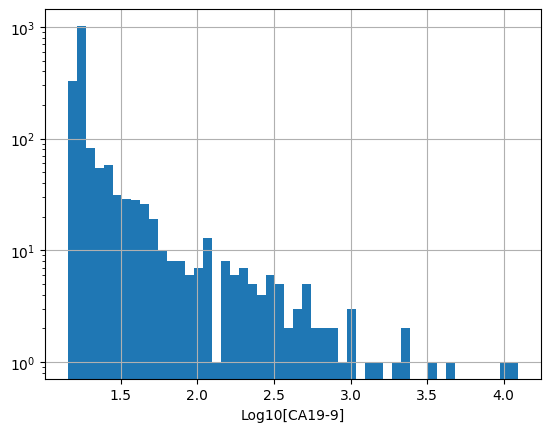

In [137]:
np.log10(df_pep['CA19-9']).hist(bins = 50, log = True)
plt.xlabel('Log10[CA19-9]')

### 다른 데이터셋 - TCGA BRCA gene expression and clinical data

In [138]:
data = load_data('tcga-brca')
data.keys()

Loading TCGA-BRCA data .. done


dict_keys(['gene_expression', 'clinical_info'])

In [139]:
df_gep = data['gene_expression']
df_clinical = data['clinical_info']

In [140]:
df_gep.shape, df_clinical.shape

((1092, 20531), (1092, 32))

In [141]:
df_gep.columns.values

array(['100130426', '100133144', '100134869', ..., 'ZZZ3', 'psiTPTE22',
       'tAKR'], shape=(20531,), dtype=object)

In [142]:
df_clinical.columns.values

array(['pid', 'age', 'gender', 'hist.type', 'menopause.status',
       'surgical.proc', 'init.metastasis', 'patho.stage', 'M.Stage',
       'N.Stage', 'T.Stage', 'Patho.Stage', 'er.status', 'pr.status',
       'her2.status', 'PAM50.class', 'subtype', 'radiation.therapy',
       'chemo.therapy', 'hormone.therapy', 'immuno.therapy',
       'ancillary.therapy', 'target.mole.therapy', 'other.therapy',
       'therapy', 'vital.status', 'days.to.event', 'cancer.status',
       'days.to.date.of.last.contact', 'days.to.date.of.death',
       'OS.event', 'OS.Time'], dtype=object)

In [143]:
df_gep.columns

Index(['100130426', '100133144', '100134869', '10357', '10431', '136542',
       '155060', '26823', '280660', '317712',
       ...
       'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX', 'ZZEF1', 'ZZZ3',
       'psiTPTE22', 'tAKR'],
      dtype='object', length=20531)

In [144]:
np.isfinite(df_gep)

,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,317712,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
TCGA.barcode,,,,,,,,,,,,,,,,,,,,,
TCGA.AR.A251.01A.12R.A169.07,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
TCGA.BH.A1FR.01A.11R.A13Q.07,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
TCGA.BH.A8G0.01A.11R.A352.07,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
TCGA.A8.A096.01A.11R.A00Z.07,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
TCGA.A8.A09E.01A.11R.A00Z.07,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA.BH.A0B0.01A.21R.A115.07,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
TCGA.UU.A93S.01A.21R.A41B.07,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
TCGA.BH.AB28.01A.31R.A41B.07,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


ValueError: supplied range of [-inf, 3.7251190567997834] is not finite

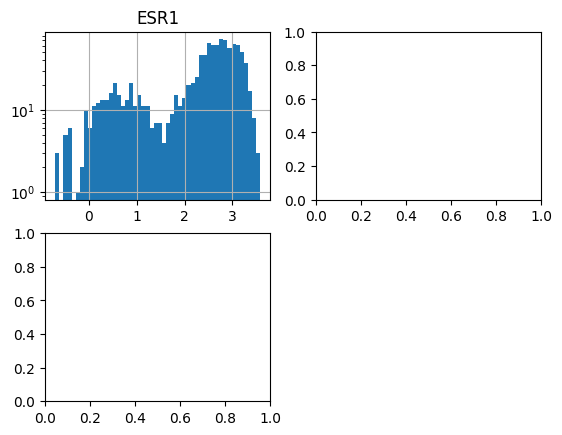

In [145]:
np.log10(df_gep[['ESR1' , 'PGR' , 'ERBB2']]).hist(bins = 50, log = True)

In [146]:
columns = df_gep.columns.tolist()
search_terms = ['ESR1', 'PGR', 'ERBB2']

found_similar_columns = {}
for term in search_terms:
    similar_cols = [col for col in columns if term.lower() in col.lower()]
    if similar_cols:
        found_similar_columns[term] = similar_cols

if found_similar_columns:
    for term, cols in found_similar_columns.items():
        print(f"'{term}'과(와) 유사한 컬럼: {cols}")
else:
    print("지정된 용어와 유사한 컬럼을 찾을 수 없습니다.")

'ESR1'과(와) 유사한 컬럼: ['ESR1']
'PGR'과(와) 유사한 컬럼: ['PGRMC1', 'PGRMC2', 'PGR', 'RPGRIP1L', 'RPGRIP1', 'RPGR']
'ERBB2'과(와) 유사한 컬럼: ['ERBB2IP', 'ERBB2']


array([[<Axes: title={'center': 'ESR1'}>,
        <Axes: title={'center': 'PGR'}>],
       [<Axes: title={'center': 'ERBB2'}>, <Axes: >]], dtype=object)

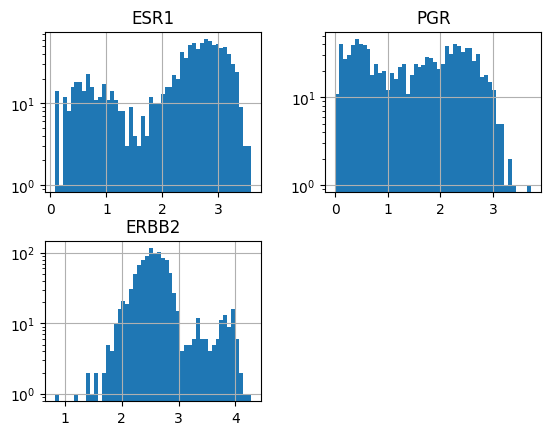

In [147]:
np.log10(1 + df_gep[['ESR1' , 'PGR' , 'ERBB2']]).hist(bins = 50, log = True)

In [148]:
print(df_gep.columns.tolist())

['100130426', '100133144', '100134869', '10357', '10431', '136542', '155060', '26823', '280660', '317712', '340602', '388795', '390284', '391343', '391714', '404770', '441362', '442388', '553137', '57714', '645851', '652919', '653553', '728045', '728603', '728788', '729884', '8225', '90288', 'A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2ML1', 'A2M', 'A4GALT', 'A4GNT', 'AAA1', 'AAAS', 'AACSL', 'AACS', 'AADACL2', 'AADACL3', 'AADACL4', 'AADAC', 'AADAT', 'AAGAB', 'AAK1', 'AAMP', 'AANAT', 'AARS2', 'AARSD1', 'AARS', 'AASDHPPT', 'AASDH', 'AASS', 'AATF', 'AATK', 'ABAT', 'ABCA10', 'ABCA11P', 'ABCA12', 'ABCA13', 'ABCA17P', 'ABCA1', 'ABCA2', 'ABCA3', 'ABCA4', 'ABCA5', 'ABCA6', 'ABCA7', 'ABCA8', 'ABCA9', 'ABCB10', 'ABCB11', 'ABCB1', 'ABCB4', 'ABCB5', 'ABCB6', 'ABCB7', 'ABCB8', 'ABCB9', 'ABCC10', 'ABCC11', 'ABCC12', 'ABCC13', 'ABCC1', 'ABCC2', 'ABCC3', 'ABCC4', 'ABCC5', 'ABCC6P1', 'ABCC6P2', 'ABCC6', 'ABCC8', 'ABCC9', 'ABCD1', 'ABCD2', 'ABCD3', 'ABCD4', 'ABCE1', 'ABCF1', 'ABCF2', 'ABCF3', 'ABCG1', 'ABCG2', 

In [149]:
df_clinical['Patho.Stage'].value_counts(), df_clinical['patho.stage'].value_counts()

(Patho.Stage
 II     616
 III    247
 I      180
 IV      20
 X       14
 Name: count, dtype: int64,
 patho.stage
 stage iia     356
 stage iib     254
 stage iiia    153
 stage i        89
 stage ia       85
 stage iiic     65
 stage iiib     27
 stage iv       20
 stage x        14
 stage ib        6
 stage ii        6
 stage iii       2
 Name: count, dtype: int64)

In [150]:
df_clinical.head()

,pid,age,gender,hist.type,menopause.status,surgical.proc,init.metastasis,patho.stage,M.Stage,N.Stage,...,target.mole.therapy,other.therapy,therapy,vital.status,days.to.event,cancer.status,days.to.date.of.last.contact,days.to.date.of.death,OS.event,OS.Time
TCGA.barcode,,,,,,,,,,,,,,,,,,,,,
TCGA.AR.A251.01A.12R.A169.07,TCGA.AR.A251,51.0,female,infiltrating ductal carcinoma,pre,other,NaN,stage iiia,M0,N2,...,0,0,BOTH,alive,3030.0,tumor free,1373.0,NaN,0.0,3030.0
TCGA.BH.A1FR.01A.11R.A13Q.07,TCGA.BH.A1FR,73.0,female,"other, specify",NaN,other,NaN,stage iiib,M0,N1,...,0,0,NO,dead,1642.0,with tumor,1642.0,1642.0,1.0,1642.0
TCGA.BH.A8G0.01A.11R.A352.07,TCGA.BH.A8G0,54.0,female,infiltrating lobular carcinoma,peri,simple mastectomy,NaN,stage iib,M0,N1,...,0,0,CO,alive,662.0,tumor free,662.0,NaN,0.0,662.0
TCGA.A8.A096.01A.11R.A00Z.07,TCGA.A8.A096,73.0,female,infiltrating ductal carcinoma,post,other,NaN,stage iia,M0,N0,...,0,0,NO,alive,0.0,tumor free,0.0,NaN,0.0,0.0
TCGA.A8.A09E.01A.11R.A00Z.07,TCGA.A8.A09E,73.0,female,infiltrating ductal carcinoma,post,other,NaN,stage iiib,M0,N1,...,0,0,HO,alive,943.0,with tumor,942.0,NaN,0.0,943.0


In [151]:
df_clinical.columns.values

array(['pid', 'age', 'gender', 'hist.type', 'menopause.status',
       'surgical.proc', 'init.metastasis', 'patho.stage', 'M.Stage',
       'N.Stage', 'T.Stage', 'Patho.Stage', 'er.status', 'pr.status',
       'her2.status', 'PAM50.class', 'subtype', 'radiation.therapy',
       'chemo.therapy', 'hormone.therapy', 'immuno.therapy',
       'ancillary.therapy', 'target.mole.therapy', 'other.therapy',
       'therapy', 'vital.status', 'days.to.event', 'cancer.status',
       'days.to.date.of.last.contact', 'days.to.date.of.death',
       'OS.event', 'OS.Time'], dtype=object)

In [152]:
df_gep.shape, df_clinical.shape

((1092, 20531), (1092, 32))

In [153]:
df_gep

,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,317712,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
TCGA.barcode,,,,,,,,,,,,,,,,,,,,,
TCGA.AR.A251.01A.12R.A169.07,0.0,5.2,0.9,2.9,94.9,0.0,7.1,0.1,0.0,0.0,...,2.3,24.8,77.4,17.9,81.1,153.3,140.6,99.2,23.6,0.0
TCGA.BH.A1FR.01A.11R.A13Q.07,0.0,0.4,0.1,2.8,42.0,0.0,12.9,0.0,0.0,0.0,...,4.9,53.2,66.4,3.5,58.0,128.0,87.3,95.3,12.3,0.0
TCGA.BH.A8G0.01A.11R.A352.07,0.0,0.4,0.9,3.8,32.5,0.0,22.3,0.0,0.0,0.0,...,3.4,22.8,54.0,6.2,37.2,258.8,100.6,49.3,24.5,0.0
TCGA.A8.A096.01A.11R.A00Z.07,0.0,0.1,0.2,4.8,36.3,0.0,2.8,0.0,0.0,0.0,...,4.0,23.9,56.2,0.2,41.7,167.7,80.4,60.4,1.3,0.0
TCGA.A8.A09E.01A.11R.A00Z.07,0.0,0.2,0.4,4.2,37.0,0.0,21.8,0.0,0.0,0.0,...,3.9,27.9,70.6,1.8,38.1,121.8,70.9,22.3,1.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA.BH.A0B0.01A.21R.A115.07,0.0,0.2,0.2,5.5,62.3,0.0,4.9,0.0,0.0,0.0,...,3.9,22.2,47.4,3.1,31.2,193.5,48.8,41.2,3.6,0.0
TCGA.UU.A93S.01A.21R.A41B.07,0.0,0.2,0.5,6.7,141.7,0.0,9.0,0.0,0.0,0.0,...,1.0,9.9,44.6,0.6,27.5,274.7,26.4,19.0,0.4,0.0
TCGA.BH.AB28.01A.31R.A41B.07,0.0,0.6,0.9,5.4,32.5,0.0,17.6,0.1,0.0,0.0,...,4.8,43.2,68.8,1.6,47.3,226.5,123.1,37.8,3.9,0.0


In [154]:
df_gep.sum(axis = 1)

,0
TCGA.barcode,
TCGA.AR.A251.01A.12R.A169.07,999975.8
TCGA.BH.A1FR.01A.11R.A13Q.07,999951.2
TCGA.BH.A8G0.01A.11R.A352.07,999973.1
TCGA.A8.A096.01A.11R.A00Z.07,999975.8
TCGA.A8.A09E.01A.11R.A00Z.07,999984.9
...,...
TCGA.BH.A0B0.01A.21R.A115.07,999990.5
TCGA.UU.A93S.01A.21R.A41B.07,999974.4
TCGA.BH.AB28.01A.31R.A41B.07,999976.7


### DataFrame 활용 연습
1. head() method를 이용한 Data frame 확인: head(), tail()
2. shape attribute를 이용한 size 확인: shape
3. row name(index) 및 column name 확인
4. index/column name을 이용한 행/열 가져오기: loc(), iloc()
5. pandas series
6. NA(None)이 포함된 element 확인하기: isnull()
7. 행/열의 합/평균/표준편차 구하기: sum(), mean(), std()
8. 행/열의 최대값/최소값/최대값의 index 구하기: max(), min(), idxmax(), idxmin()
9. 범주형 데이터의 범주 카운트 구하기: value_counts()
10. 조건에 맞는 행들만 선택하기 - boolean indexing
11. 범주형 데이터가 특정 집합의 원소인지 아닌지 조사하기: isin()
12. 등호/부등호의 사용: ==, >, <
13. 특정 열 기준으로 정렬하기: sort_values()

In [155]:
df_gep.sort_values(by = 'ESR1' , ascending = True)

,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,317712,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
TCGA.barcode,,,,,,,,,,,,,,,,,,,,,
TCGA.E2.A158.01A.11R.A12D.07,0.0,2.9,2.2,3.6,56.7,0.0,24.9,0.1,0.0,0.0,...,3.2,31.8,90.2,19.0,44.3,384.1,40.6,94.3,53.4,0.0
TCGA.AQ.A54N.01A.11R.A266.07,0.0,0.0,0.3,7.4,141.3,0.0,28.1,0.0,0.0,0.0,...,1.0,10.2,72.1,10.1,26.0,407.2,55.5,30.3,17.3,0.0
TCGA.A2.A3XV.01A.21R.A239.07,0.0,0.0,0.2,3.5,94.2,0.0,11.8,0.0,0.0,0.0,...,0.3,7.8,23.2,11.1,16.3,246.8,16.0,15.3,0.6,0.0
TCGA.A2.A0D0.01A.11R.A00Z.07,0.0,0.1,0.1,11.5,65.6,0.0,5.8,0.0,0.0,0.0,...,0.9,11.9,81.0,15.2,48.6,411.5,25.1,46.6,0.2,0.0
TCGA.A2.A04U.01A.11R.A115.07,0.0,0.0,0.0,20.5,218.4,0.0,3.9,0.0,0.0,0.0,...,0.9,8.7,43.6,6.5,29.3,160.4,30.7,62.9,4.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA.E9.A1R7.01A.11R.A14M.07,0.0,0.6,0.3,5.6,62.4,0.0,7.3,0.1,0.0,0.0,...,4.5,45.6,69.2,33.2,110.0,48.1,51.1,61.9,0.5,0.0
TCGA.AQ.A1H2.01A.11R.A13Q.07,0.0,0.4,0.2,1.9,54.5,0.0,5.2,0.1,0.0,0.0,...,4.3,37.3,57.3,3.7,61.2,73.1,65.9,42.2,0.4,0.0
TCGA.D8.A1XC.01A.11R.A14D.07,0.0,0.2,0.3,2.7,28.6,0.0,5.8,0.1,0.0,0.0,...,6.2,51.5,75.6,1.5,51.2,102.5,111.1,106.9,0.4,0.0


In [156]:
b = df_gep['ESR1'] >=10
df_gep.loc[b].shape
df_gep.loc[b]

,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,317712,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
TCGA.barcode,,,,,,,,,,,,,,,,,,,,,
TCGA.AR.A251.01A.12R.A169.07,0.0,5.2,0.9,2.9,94.9,0.0,7.1,0.1,0.0,0.0,...,2.3,24.8,77.4,17.9,81.1,153.3,140.6,99.2,23.6,0.0
TCGA.BH.A1FR.01A.11R.A13Q.07,0.0,0.4,0.1,2.8,42.0,0.0,12.9,0.0,0.0,0.0,...,4.9,53.2,66.4,3.5,58.0,128.0,87.3,95.3,12.3,0.0
TCGA.BH.A8G0.01A.11R.A352.07,0.0,0.4,0.9,3.8,32.5,0.0,22.3,0.0,0.0,0.0,...,3.4,22.8,54.0,6.2,37.2,258.8,100.6,49.3,24.5,0.0
TCGA.A8.A096.01A.11R.A00Z.07,0.0,0.1,0.2,4.8,36.3,0.0,2.8,0.0,0.0,0.0,...,4.0,23.9,56.2,0.2,41.7,167.7,80.4,60.4,1.3,0.0
TCGA.A8.A09E.01A.11R.A00Z.07,0.0,0.2,0.4,4.2,37.0,0.0,21.8,0.0,0.0,0.0,...,3.9,27.9,70.6,1.8,38.1,121.8,70.9,22.3,1.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA.EW.A1J2.01A.21R.A13Q.07,0.0,0.8,0.4,3.1,35.1,0.0,10.8,0.1,0.0,0.0,...,5.1,35.4,67.8,8.0,63.2,199.2,82.6,72.0,3.2,0.0
TCGA.A2.A0CT.01A.31R.A056.07,0.0,0.0,0.3,3.3,50.1,0.0,1.4,0.0,0.0,0.0,...,5.9,135.0,58.2,1.5,50.5,59.0,71.2,45.0,3.5,0.0
TCGA.BH.A0B0.01A.21R.A115.07,0.0,0.2,0.2,5.5,62.3,0.0,4.9,0.0,0.0,0.0,...,3.9,22.2,47.4,3.1,31.2,193.5,48.8,41.2,3.6,0.0


In [157]:
df_clinical['init.metastasis'].values

array([nan, nan, nan, ..., nan, 'no', nan], shape=(1092,), dtype=object)

In [158]:
df_clinical.isnull().sum()

,0
pid,0
age,7
gender,7
hist.type,8
menopause.status,96
surgical.proc,63
init.metastasis,699
patho.stage,15
M.Stage,7
N.Stage,7


In [ ]:
# TCGA-BRCA gene expression table과 clinical table을 이용해 DataFrame 기본기를 연습합니다.

print('gene expression shape:', df_gep.shape)
print('clinical info shape:', df_clinical.shape)

# 1) 앞/뒤 일부 행 확인
print('--- df_gep head ---')
display(df_gep.head())

print('--- df_clinical head ---')
display(df_clinical.head())

### DataFrame 핵심 조작 예제

아래 셀들은 실제 분석에서 거의 매번 쓰는 조작입니다.  
처음에는 코드를 외우기보다, “행을 고르는지, 열을 고르는지, 조건을 거는지”를 구분해서 읽는 것이 중요합니다.

In [ ]:
# 열 이름 확인
print(df_gep.columns[:10])
print(df_clinical.columns)

# 관심 유전자 3개만 선택
marker_genes = ['ESR1', 'ERBB2', 'MKI67']
df_marker = df_gep[marker_genes]

df_marker.head()

In [ ]:
# loc: index/column 이름으로 선택
# iloc: 행/열 번호 위치로 선택

print('첫 번째 샘플 ID:', df_gep.index[0])

display(df_gep.loc[df_gep.index[0], marker_genes])
display(df_gep.iloc[:5, :5])

In [ ]:
# 임상 정보에서 subtype별 샘플 수 확인
# value_counts()는 범주형 변수의 분포를 볼 때 자주 사용합니다.

df_clinical['subtype'].value_counts(dropna=False)

In [ ]:
# gene expression과 clinical subtype을 하나의 DataFrame으로 합치기
# 두 table의 index가 같은 sample ID라고 가정하고 열 방향(axis=1)으로 붙입니다.

practice_df = pd.concat([
    df_gep[marker_genes],
    df_clinical[['subtype']]
], axis=1)

practice_df.head()

In [ ]:
# 조건 필터링: Basal-like 샘플만 선택
basal_df = practice_df[practice_df['subtype'] == 'Basal']

print(basal_df.shape)
basal_df.head()

In [ ]:
# groupby: subtype별 marker gene 평균과 표준편차 계산
summary_mean = practice_df.groupby('subtype')[marker_genes].mean()
summary_std = practice_df.groupby('subtype')[marker_genes].std()

print('Subtype별 평균')
display(summary_mean)

print('Subtype별 표준편차')
display(summary_std)

### 다른 데이터셋 - CCLE cellline gene expression and drug response measurement

In [ ]:
data = load_data('ccle-ctrpv2')
data.keys()

In [ ]:
df_gexp = data['gene_expression']
df_cl_info = data['cellline_info']
df_auc = data['auc']
df_ec50 = data['ec50']
df_drug_info = data['drug_info']

### Homework

유방암은 크게 3가지의 subtype (Basal-like, Luminal 및 Her2)으로 구분한다. 또한, Lum.subtype은 다시 liminal A와 Luminal B로 나뉜다. 이들 subtype들은 대체로 3가지 유전자(ESR1, ERBB2, MKI67)의 발현량에 따라 구분되기도 한다. 3가지의 subtype (Basal-like, Luminal 및 Her2) 각각에 대해 3가지 유전자 (ESR1, ERBB2, MKI67)의 발현량의 평균과 표준편자를 각각 구하여 data frame으로 요약해 보아라. 이 때 data frame의 index는 subtype의 이름, columns는 유전자 이름으로 설정하라. (예, 'ESR1 (mean)', 'ESR1 (stdev)' 등) 이를 위해 필요한 정보는 TCGA-BRCA 데이터에 모두 포함되어 있으며 해당 데이터를 잘 살펴보고 필요 시 다음의 인터넷 사이트를 참고하라. NA가 포함된 부분은 적절히 제외하라.
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html    

#### Homework 접근 힌트

1. `df_gep[['ESR1', 'ERBB2', 'MKI67']]`로 관심 유전자만 고릅니다.
2. `df_clinical[['subtype']]`을 함께 붙여 분석용 DataFrame을 만듭니다.
3. `dropna()`로 subtype 또는 발현량 결측치를 정리합니다.
4. `groupby('subtype')` 뒤에 `mean()`과 `std()`를 적용합니다.
5. 결과를 보기 좋은 하나의 DataFrame으로 정리합니다.

In [ ]:
# Homework template
# 아래 빈칸을 채워 subtype별 ESR1/ERBB2/MKI67 평균과 표준편차를 계산해 보세요.

marker_genes = ['ESR1', 'ERBB2', 'MKI67']

hw_df = pd.concat([
    df_gep[marker_genes],
    df_clinical[['subtype']]
], axis=1)

hw_df = hw_df.dropna(subset=marker_genes + ['subtype'])

# subtype_summary = ...
# subtype_summary

## 2. 데이터 분포의 시각화 연습

시각화는 “분석 결과를 예쁘게 보여주는 단계”라기보다, 데이터가 어떤 모양인지 먼저 확인하는 탐색 과정입니다.  
특히 바이오 데이터에서는 극단값, subtype별 차이, marker gene 간 관계를 눈으로 확인하는 과정이 중요합니다.

1. Histogram: 한 변수의 전체 분포
2. Pairplot: 여러 변수 간 관계
3. Box plot: 그룹별 분포 비교
4. Violin plot: 그룹별 분포 모양 비교
5. Heatmap / clustermap: 여러 유전자 패턴 비교

In [159]:
data = load_data('tcga-brca')

df_gep = data['gene_expression']
df_clinical = data['clinical_info']

Loading TCGA-BRCA data .. done


In [161]:
df_gep.shape

(1092, 20531)

In [176]:
df_log_gep = np.log10(df_gep + 1)

In [ ]:
df_gep['ESR1'].hist()

<Axes: >

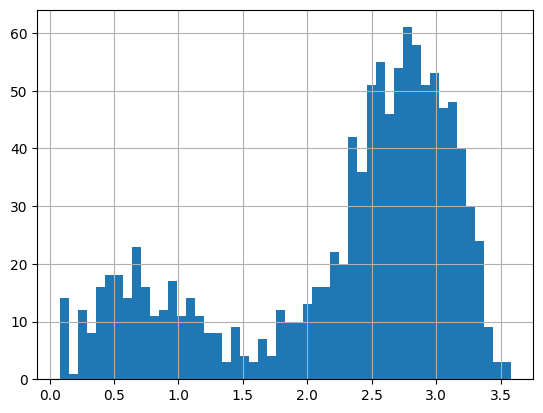

In [180]:
df_log_gep['ESR1'].hist(bins = 50)
#

Text(0.5, 1.0, 'Gene Expression of ESR1 and ERBB2')

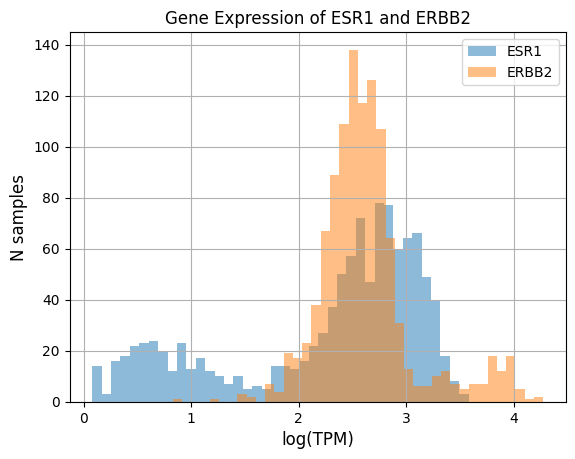

In [182]:
df_log_gep['ESR1'].hist(bins = 40, alpha = 0.5)
#alpha는 투명도 (1이면 중첩되서 안보임)
df_log_gep['ERBB2'].hist(bins = 40, alpha = 0.5)

plt.xlabel('log(TPM)', fontsize = 12)
# x label ,y label 달기
plt.ylabel('N samples', fontsize = 12)
plt.legend(['ESR1', 'ERBB2'])
plt.title('Gene Expression of ESR1 and ERBB2')
# legend는 설명

In [183]:
df_clinical.info()
# 범주가 2개면 label encoding, 3개 이상이면 Onehot encoding으로 수치화 해야됨!

<class 'pandas.core.frame.DataFrame'>
Index: 1092 entries, TCGA.AR.A251.01A.12R.A169.07 to TCGA.PL.A8LV.01A.21R.A41B.07
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   pid                           1092 non-null   object 
 1   age                           1085 non-null   float64
 2   gender                        1085 non-null   object 
 3   hist.type                     1084 non-null   object 
 4   menopause.status              996 non-null    object 
 5   surgical.proc                 1029 non-null   object 
 6   init.metastasis               393 non-null    object 
 7   patho.stage                   1077 non-null   object 
 8   M.Stage                       1085 non-null   object 
 9   N.Stage                       1085 non-null   object 
 10  T.Stage                       1085 non-null   object 
 11  Patho.Stage                   1077 non-null   object 
 12  er.status       

In [184]:
df_clinical['er.status'].value_counts()
# 3개지만 1, -1, 0로 label encoding 해도됨 (inderterminate는 positive와 negetive 사이에 있다고 판단할 수 있으니까)

,count
er.status,
positive,800
negative,235
indeterminate,2


In [189]:
df_clinical['therapy'].value_counts()
# NO(00), Both(11) 등으로 label encoding 가능할듯하다고..? > 교수님 설명이긴 한데 아닌듯..?
#Both는 1100, NO는

,count
therapy,
NO,325
BOTH,320
CO,254
HO,193


### 'therapy' 컬럼 이진 인코딩

'therapy' 컬럼의 특성(`'BOTH'`가 `'CO'`와 `'HO'`를 모두 포함)을 반영하기 위해 각 치료 유형에 대한 이진(binary) 컬럼을 생성합니다.

In [190]:
# df_clinical의 복사본을 만들어 원본 DataFrame을 보호합니다.
df_therapy_encoded = df_clinical[['therapy']].copy()

# 'has_CO_therapy' 컬럼 생성
# 'CO' 또는 'BOTH'인 경우 1, 그 외 0
df_therapy_encoded['has_CO_therapy'] = df_therapy_encoded['therapy'].apply(lambda x: 1 if x in ['CO', 'BOTH'] else 0)

# 'has_HO_therapy' 컬럼 생성
# 'HO' 또는 'BOTH'인 경우 1, 그 외 0
df_therapy_encoded['has_HO_therapy'] = df_therapy_encoded['therapy'].apply(lambda x: 1 if x in ['HO', 'BOTH'] else 0)

# 'has_NO_therapy' 컬럼 생성
# 'NO'인 경우 1, 그 외 0
df_therapy_encoded['has_NO_therapy'] = df_therapy_encoded['therapy'].apply(lambda x: 1 if x == 'NO' else 0)


print("새로 생성된 이진 컬럼들의 value_counts:")
display(df_therapy_encoded[['has_CO_therapy', 'has_HO_therapy', 'has_NO_therapy']].value_counts())

print("\n인코딩된 DataFrame의 head():")
display(df_therapy_encoded.head())

새로 생성된 이진 컬럼들의 value_counts:


has_CO_therapy  has_HO_therapy  has_NO_therapy
0               0               1                 325
1               1               0                 320
                0               0                 254
0               1               0                 193
Name: count, dtype: int64


인코딩된 DataFrame의 head():


,therapy,has_CO_therapy,has_HO_therapy,has_NO_therapy
TCGA.barcode,,,,
TCGA.AR.A251.01A.12R.A169.07,BOTH,1,1,0
TCGA.BH.A1FR.01A.11R.A13Q.07,NO,0,0,1
TCGA.BH.A8G0.01A.11R.A352.07,CO,1,0,0
TCGA.A8.A096.01A.11R.A00Z.07,NO,0,0,1
TCGA.A8.A09E.01A.11R.A00Z.07,HO,0,1,0


In [191]:
load_data()

You can select one of:
  cancerseek
  ccle-ctrpv2
  heart_failure
  hotel_bookings
  house_price
  labor_force
  metabric
  scores
  tcga-brca
  time-series
  time-series2


In [192]:
load_data('scores')

,Group,English,Math,Science
0,A,77,72,75
1,A,81,67,68
2,A,74,74,72
3,A,89,64,68
4,A,78,71,74
...,...,...,...,...
95,B,75,81,77
96,B,65,84,77
97,B,75,77,73
98,B,72,82,79


#### pair wise scatter plot 그리기

In [164]:
df = df_log_gep[['ESR1', 'ERBB2', 'MKI67']].copy(deep = True)
df['subtype'] = df_clinical['subtype'].copy(deep=True)
# subtype이라는 열 추가 (3개 발현양을 보고 결정 / 색 추가하려고)
df

,ESR1,ERBB2,MKI67,subtype
TCGA.barcode,,,,
TCGA.AR.A251.01A.12R.A169.07,1.320146,2.166430,2.651375,Basal
TCGA.BH.A1FR.01A.11R.A13Q.07,3.412712,2.401228,1.666518,Lum.A
TCGA.BH.A8G0.01A.11R.A352.07,2.466868,2.672098,1.127105,Lum.A
TCGA.A8.A096.01A.11R.A00Z.07,2.899821,2.492621,2.168792,Lum.A
TCGA.A8.A09E.01A.11R.A00Z.07,3.065356,2.880070,1.899273,Lum.B
...,...,...,...,...
TCGA.BH.A0B0.01A.21R.A115.07,2.474508,2.284431,1.685742,Lum.A
TCGA.UU.A93S.01A.21R.A41B.07,0.707570,4.271707,1.973128,Her2
TCGA.BH.AB28.01A.31R.A41B.07,2.963079,2.997648,1.830589,Lum.A


In [165]:
df['subtype'].value_counts()

,count
subtype,
Lum.A,622
Basal,196
Lum.B,187
Her2,87


In [166]:
df.head()

,ESR1,ERBB2,MKI67,subtype
TCGA.barcode,,,,
TCGA.AR.A251.01A.12R.A169.07,1.320146,2.166430,2.651375,Basal
TCGA.BH.A1FR.01A.11R.A13Q.07,3.412712,2.401228,1.666518,Lum.A
TCGA.BH.A8G0.01A.11R.A352.07,2.466868,2.672098,1.127105,Lum.A
TCGA.A8.A096.01A.11R.A00Z.07,2.899821,2.492621,2.168792,Lum.A
TCGA.A8.A09E.01A.11R.A00Z.07,3.065356,2.880070,1.899273,Lum.B


In [167]:
df['subtype'].value_counts()

,count
subtype,
Lum.A,622
Basal,196
Lum.B,187
Her2,87


#### Pairplot 해석 포인트

각 점은 한 환자 샘플이고, 색은 유방암 subtype입니다.  
`ESR1`, `ERBB2`, `MKI67` 세 유전자만으로도 일부 subtype이 서로 다른 위치에 모이는지 관찰해 봅니다.

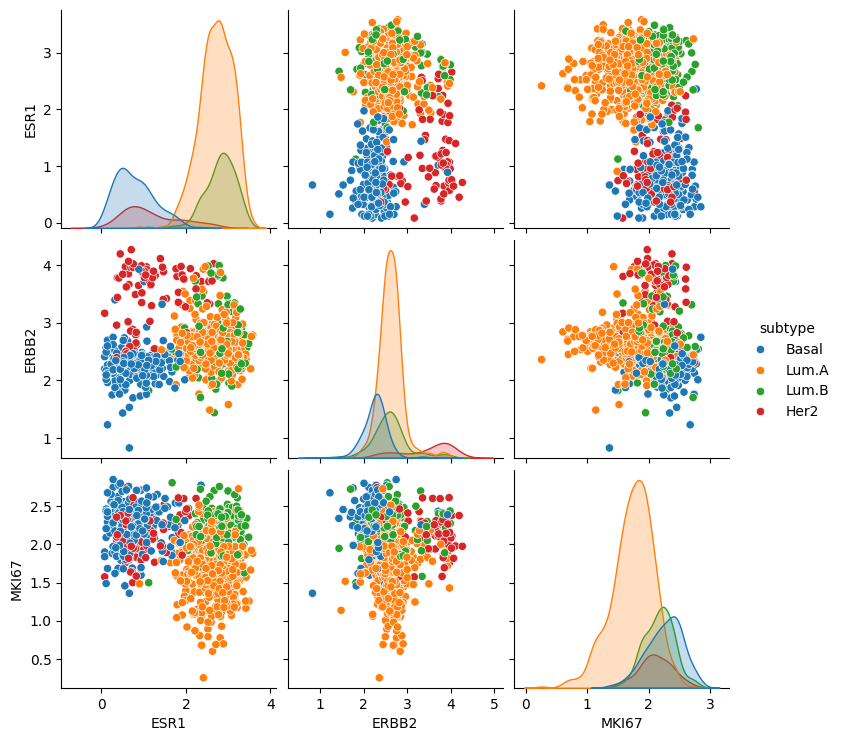

In [168]:
## Pairplot with hue
sns.pairplot(df, hue = 'subtype', diag_kind = 'kde')
# sns는 시본패키지 (seaborn), kde는 smoth하게 만드는 것
# 특징계수가 많지않을때 사용 / 많아지면 보기 어려워진다.

#### Box plot 그리기

<Axes: >

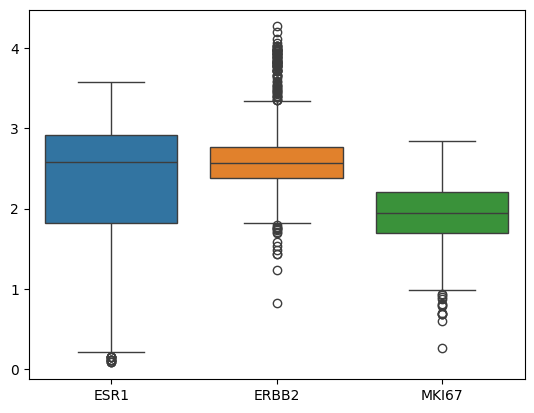

In [169]:
sns.boxplot(data = df.iloc[:,:3])
# 분포의 방식을 정량화해서 보는것 / 가운데는 median
# 그룹핑을 따로 안했을 때의 그래프

<Axes: xlabel='subtype', ylabel='ERBB2'>

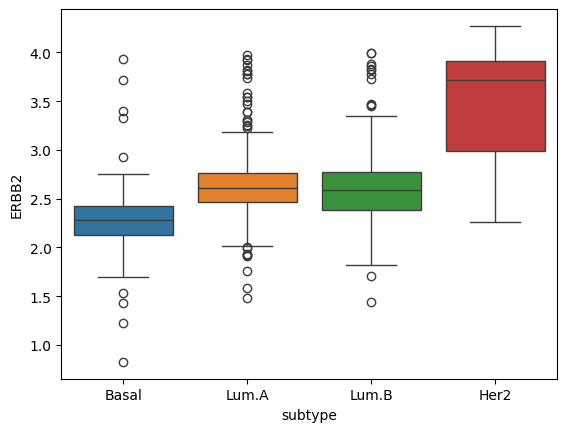

In [170]:
sns.boxplot(data = df, y = 'ERBB2', x = 'subtype', hue = 'subtype')
# ERBB2만 선택해서 subtype의 그룹별로 그래프 확인한 것

<Axes: xlabel='subtype', ylabel='ESR1'>

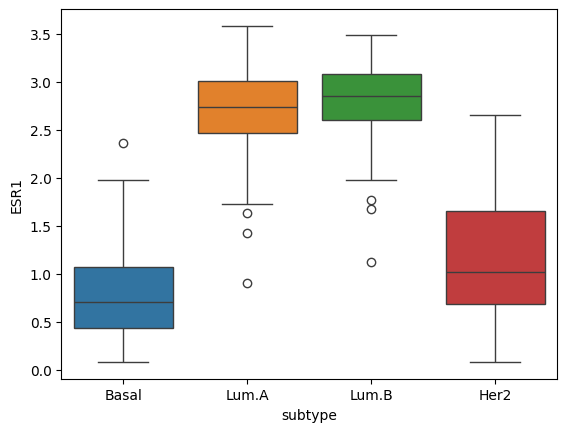

In [193]:
sns.boxplot(data = df, y = 'ESR1', x = 'subtype', hue = 'subtype')

#### Violin plot 그리기

<Axes: xlabel='subtype', ylabel='ERBB2'>

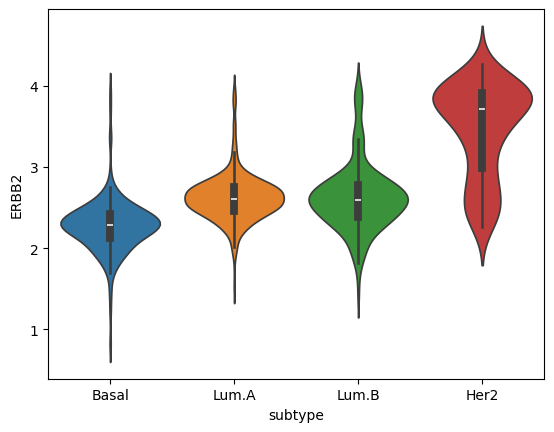

In [171]:
sns.violinplot(data = df, y = 'ERBB2', x = 'subtype', hue = 'subtype')

#### Heatmap 그리기

In [172]:
PAM50_genes = ['ACTR3B', 'ANLN', 'BAG1', 'BCL2', 'BIRC5', 'BLVRA',
 'CCNB1', 'CCNE1', 'CDC20', 'CDC6', 'CDH3', 'CENPF', 'CEP55',
 'CXXC5', 'EGFR', 'ERBB2', 'ESR1', 'EXO1', 'FGFR4', 'FOXA1',
 'FOXC1', 'GPR160', 'GRB7', 'KIF2C', 'KRT14', 'KRT17', 'KRT5',
 'MAPT', 'MDM2', 'MELK', 'MIA', 'MKI67', 'MLPH', 'MMP11', 'MYBL2',
 'MYC', 'NAT1', 'NDC80', 'NUF2', 'ORC6L', 'PGR', 'PHGDH', 'PTTG1',
 'RRM2', 'SFRP1', 'SLC39A6', 'TMEM45B', 'TYMS', 'UBE2C', 'UBE2T']

PAM50_genes = list(set(PAM50_genes).intersection(df_log_gep.columns.values))
len(PAM50_genes)

50

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(1163.6527777777778, 0.5, 'Gene')

<Figure size 960x400 with 0 Axes>

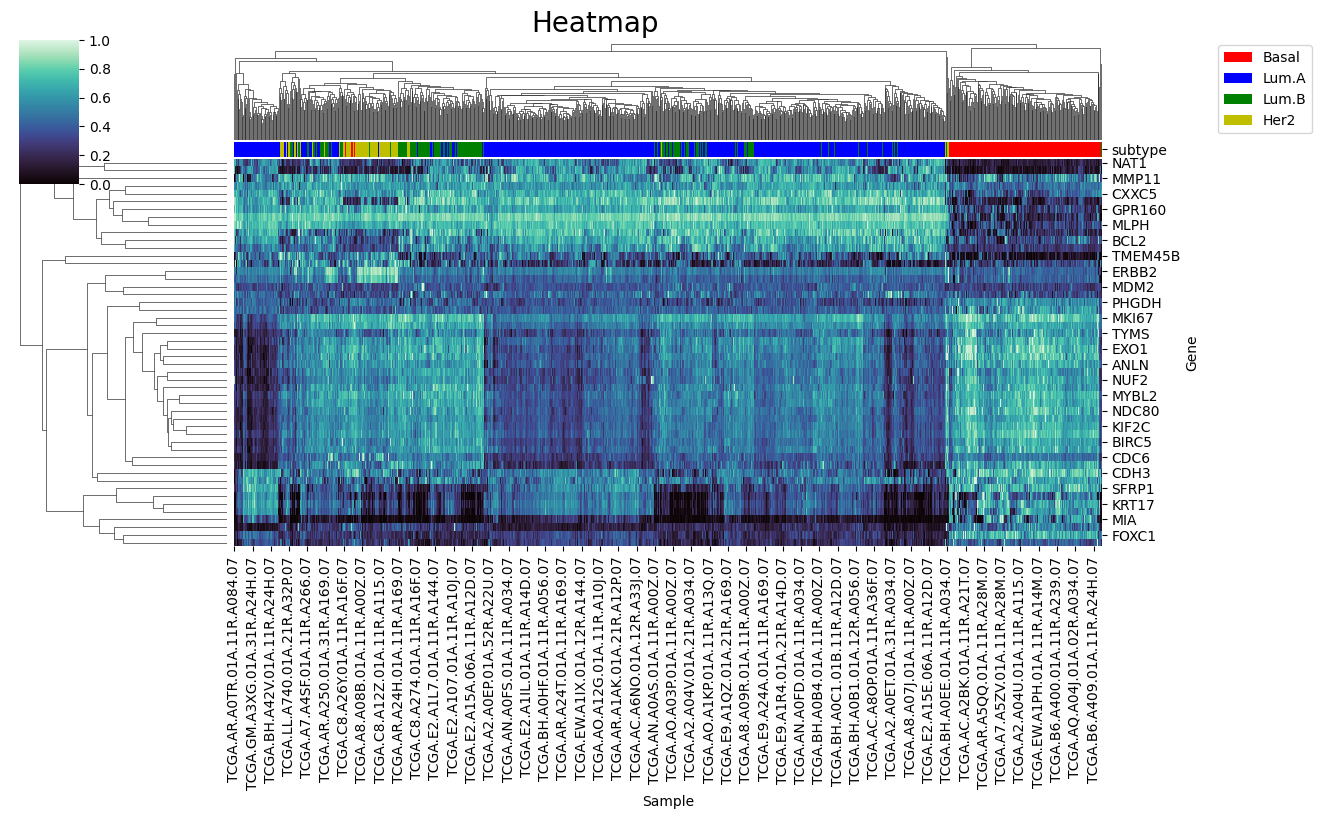

In [173]:
X_sel = df_log_gep[PAM50_genes] # .copy(deep=True)
# X_sel = df_log_gep[['ESR1', 'ERBB2', 'MKI67']]
y = df_clinical['subtype']

plt.figure(num=None, figsize=(12, 5), dpi=80, facecolor='w', edgecolor='k')
# ax = sb.heatmap(X_sel.transpose())

lut = dict(zip(set(y), "rbgym"))
col_colors = y.map(lut)
dfc = pd.DataFrame([col_colors]).transpose()

g = sns.clustermap(X_sel.transpose(), col_cluster = True, row_cluster = True, standard_scale = 0,
                   col_colors = dfc, cmap="mako", figsize = (12,8))
g.fig.suptitle('Heatmap\n ', fontsize=20, va = 'center')

# Draw the legend bar for the classes
for label in list(set(y)):
    g.ax_col_dendrogram.bar(0, 0, color=lut[label],
                            label=label, linewidth=0)
g.ax_col_dendrogram.legend(loc="center right", bbox_to_anchor=(1.25, 0.5), ncol=1)
# ax.cax.set_position([.2, .2, .03, 1])
g.ax_heatmap.set_xlabel('Sample')
g.ax_heatmap.set_ylabel('Gene')

### Homework

유방암은 크게 3가지의 subtype (Basal-like, Luminal 및 HER2-enriched)으로 구분한다. 또한, Luminal subtype은 다시 liminal A와 Luminal B로 나뉜다. 이들 subtype들은 대체로 3가지 유전자(ESR1, ERBB2, MKI67)의 발현량에 따라 구분되기도 한다.

1. 3가지의 subtype (Basal-like, Luminal 및 HER2-enriched) 각각에 대해 3가지 유전자 (ESR1, ERBB2, MKI67)의 발현량를 Violin plot으로 그려서 비교해 보아라. NA가 포함된 부분은 적절히 제외하라.
2. 3가지의 subtype (Basal-like, Luminal 및 HER2-enriched) 각각에 대해 3가지 유전자 (ESR1, ERBB2, MKI67)의 발현량를 Cluster Map으로 그려서 비교해 보아라.
3. 1/2의 비교 굘과에 대한 간략한 고찰을 제시하여라.